In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
import scipy
import matplotlib
from matplotlib import rcParams
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # to show output from all the lines in a cells
pd.set_option('display.max_column',None) # display all the columns in pandas
pd.options.display.max_rows = 100
rcParams['pdf.fonttype'] = 42
sc.settings.figdir = './figures/figure2_S3/'
sc.settings.set_figure_params(dpi = 150, color_map = 'RdPu', dpi_save = 600, vector_friendly = True, format = 'pdf')

In [2]:
cd F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\

F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline


G:\Miniconda3\envs\omicverse\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
data_dir = '/PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/'
meta = pd.read_csv(data_dir+'metadata.csv',index_col=0)
meta

,sample_id,donor,gw,gender,10xKit,sequencing,dataset,species
sample,,,,,,,,
9.5gw,gw9,not_provided_1,9,female,SC3,snRNA-seq,public,Homo sapiens
11.2gw,gw11,not_provided_2,11,male,SC3,snRNA-seq,public,Homo sapiens
14+3gw,gw14,F20240701,14,male,SC3,snRNA-seq,in-house,Homo sapiens
15gw,gw15,not_provided_3,15,female,SC3,scRNA-seq,public,Homo sapiens
16+4gw,gw16,F20241018,16,male,SC3,snRNA-seq,in-house,Homo sapiens
17+2gw,gw17_1,F20220807,17,male,SC3,snRNA-seq,in-house,Homo sapiens
17+3gw,gw17_2,F20240928,17,female,SC3,snRNA-seq,in-house,Homo sapiens
17gw,gw17_3,not_provided_4,17,male,SC3,scRNA-seq,public,Homo sapiens
18+3gw,gw18,F20220806,18,male,SC3,snRNA-seq,in-house,Homo sapiens


In [4]:
import sctk as sk

G:\Miniconda3\envs\omicverse\lib\site-packages\sctk\_obj_utils.py:8: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  sc_warn = sc.logging.warn if sc.__version__.startswith("1.4") else sc.logging.warning
G:\Miniconda3\envs\omicverse\lib\site-packages\sctk\_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  sc_warn = sc.logging.warn if sc.__version__.startswith("1.4") else sc.logging.warning
G:\Miniconda3\envs\omicverse\lib\site-packages\sctk\_paga.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):
G:\Miniconda3\envs\omicverse\lib\site-packages\sctk\_plot.py:18: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):


In [8]:
adata_coe_raw=sc.read('human_cochlea_coe_annotation_add_40000genes.h5ad')

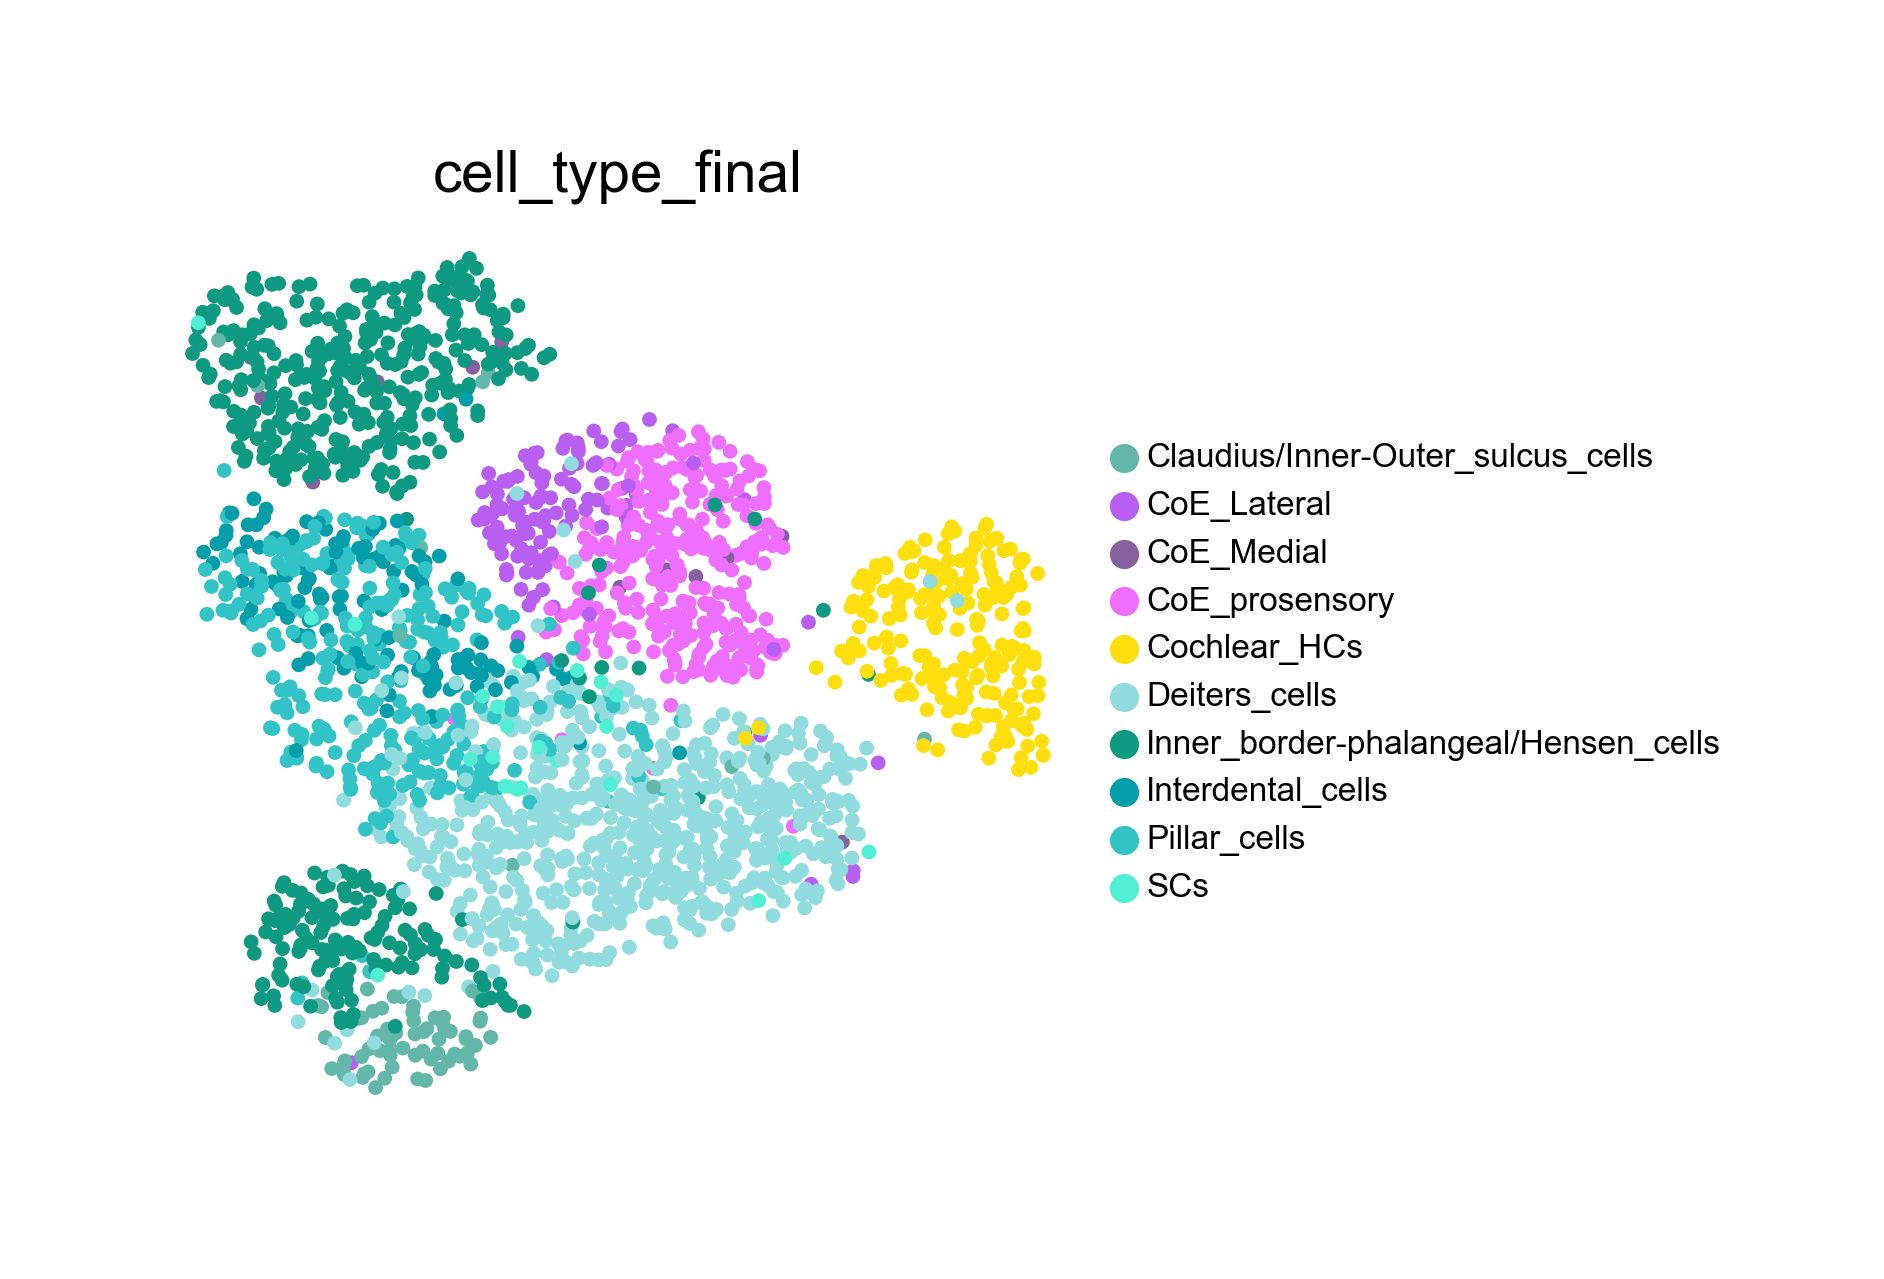

In [12]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(adata_coe_raw, color=['cell_type_final'], wspace=0.5,ncols=1,save='_human_prenatal_coe.pdf',
           legend_fontsize=8,) #legend_loc='on data',

In [5]:
import anndata as ad
import pandas as pd
import ktplotspy as kpy
import matplotlib.pyplot as plt

from pathlib import Path

In [9]:
adata_new_sub = sk.subsample(
    adata_coe_raw, 1, groupby="cell_type_final_v4", min_n=100, max_n=100
)
adata_new_sub.obs['cell_type_final_v4'].value_counts()

cell_type_final_v4
EGFR+ELMO1+HEC             100
FGFR3+PROX1+Lateral_PSD    100
FGF20+SULF1+Medial_PSD     100
FOXG1+RELN+IBC_IPhC        100
ISL1+ST3GAL1+IBC_IPhC      100
Inner_HC                   100
LGR6+TMPRSS3+_PC           100
PTGDS+CEMIP+DC             100
SERPINE2+JAG1+DC           100
SLC24A3+ZBTB20+IBC_IPhC    100
SPOCK1+PEX5L+IBC_IPhC      100
TBX2+MEIS2+Early_PSD       100
Outer_HC                    94
PPP1R2+HIST1H2AC+_PC        82
FST+AFF3+HEC                80
Name: count, dtype: int64

In [10]:
adata_new_sub_early=adata_new_sub[adata_new_sub.obs['sample_id'].isin(['gw14','gw11','gw9'])]
adata_new_sub_late=adata_new_sub[adata_new_sub.obs['sample_id'].isin(['gw16','gw23','gw25','gw22_2','gw22_1','gw18',
                                                                     'gw17_2','gw15','gw17_1','gw20','gw17_3','gw26'])]
adata_new_sub_early=adata_new_sub_early[adata_new_sub_early.obs['cell_type_final_v4'].isin(['FGFR3+PROX1+Lateral_PSD','FGF20+SULF1+Medial_PSD',
                                                                                            'Inner_HC','Outer_HC'])]
adata_new_sub_early.obs['cell_type_final_v4'].value_counts()
adata_new_sub_late=adata_new_sub_late[adata_new_sub_late.obs['cell_type_final_v4'].isin(['EGFR+ELMO1+HEC','ISL1+ST3GAL1+IBC_IPhC',
                                                                                            'LGR6+TMPRSS3+_PC','SLC24A3+ZBTB20+IBC_IPhC',
                                                                                          'SPOCK1+PEX5L+IBC_IPhC','PTGDS+CEMIP+DC',
                                                                                          'SERPINE2+JAG1+DC','FOXG1+RELN+IBC_IPhC',
                                                                                          'PPP1R2+HIST1H2AC+_PC','FST+AFF3+HEC',
                                                                                          'Inner_HC','Outer_HC'])]
adata_new_sub_late.obs['cell_type_final_v4'].value_counts()
adata_new_sub_late_OHC_DC=adata_new_sub_late[adata_new_sub_late.obs['cell_type_final_v4'].isin([
                                                                                            
                                                                                          'PTGDS+CEMIP+DC',
                                                                                          'SERPINE2+JAG1+DC',
                                                                                          
                                                                                          'Outer_HC'])]
adata_new_sub_late_OHC_DC.obs['cell_type_final_v4'].value_counts()
adata_new_sub_late_IHC_IBC_IPH=adata_new_sub_late[adata_new_sub_late.obs['cell_type_final_v4'].isin(['ISL1+ST3GAL1+IBC_IPhC',
                                                                                           'SLC24A3+ZBTB20+IBC_IPhC',
                                                                                          'SPOCK1+PEX5L+IBC_IPhC',
                                                                                          'FOXG1+RELN+IBC_IPhC',
                                                                                          
                                                                                          'Inner_HC',])]
adata_new_sub_late_IHC_IBC_IPH.obs['cell_type_final_v4'].value_counts()
adata_new_sub_early_LPSD_MPSD=adata_new_sub_early[adata_new_sub_early.obs['cell_type_final_v4'].isin(['FGFR3+PROX1+Lateral_PSD','FGF20+SULF1+Medial_PSD',
                                                                                            ])]
adata_new_sub_early_LPSD_MPSD.obs['cell_type_final_v4'].value_counts()
adata_new_sub_early_LPSD_OHC=adata_new_sub_early[adata_new_sub_early.obs['cell_type_final_v4'].isin(['FGFR3+PROX1+Lateral_PSD',
                                                                                            'Outer_HC'
                                                                                            ])]
adata_new_sub_early_LPSD_OHC.obs['cell_type_final_v4'].value_counts()
adata_new_sub_early_MPSD_IHC=adata_new_sub_early[adata_new_sub_early.obs['cell_type_final_v4'].isin(['FGF20+SULF1+Medial_PSD',
                                                                                            'Inner_HC',
                                                                                            ])]
adata_new_sub_early_MPSD_IHC.obs['cell_type_final_v4'].value_counts()

cell_type_final_v4
FGF20+SULF1+Medial_PSD     99
FGFR3+PROX1+Lateral_PSD    97
Inner_HC                   42
Outer_HC                   41
Name: count, dtype: int64

cell_type_final_v4
EGFR+ELMO1+HEC             100
ISL1+ST3GAL1+IBC_IPhC      100
LGR6+TMPRSS3+_PC           100
SLC24A3+ZBTB20+IBC_IPhC    100
SPOCK1+PEX5L+IBC_IPhC      100
PTGDS+CEMIP+DC              99
SERPINE2+JAG1+DC            99
FOXG1+RELN+IBC_IPhC         98
PPP1R2+HIST1H2AC+_PC        82
FST+AFF3+HEC                79
Inner_HC                    58
Outer_HC                    53
Name: count, dtype: int64

cell_type_final_v4
PTGDS+CEMIP+DC      99
SERPINE2+JAG1+DC    99
Outer_HC            53
Name: count, dtype: int64

cell_type_final_v4
ISL1+ST3GAL1+IBC_IPhC      100
SLC24A3+ZBTB20+IBC_IPhC    100
SPOCK1+PEX5L+IBC_IPhC      100
FOXG1+RELN+IBC_IPhC         98
Inner_HC                    58
Name: count, dtype: int64

cell_type_final_v4
FGF20+SULF1+Medial_PSD     99
FGFR3+PROX1+Lateral_PSD    97
Name: count, dtype: int64

cell_type_final_v4
FGFR3+PROX1+Lateral_PSD    97
Outer_HC                   41
Name: count, dtype: int64

cell_type_final_v4
FGF20+SULF1+Medial_PSD    99
Inner_HC                  42
Name: count, dtype: int64

In [11]:
# read in the files
# 1) .h5ad file used for performing CellPhoneDB
adata_new_sub_late_IHC_IBC_IPH

# 2) output from CellPhoneDB
means = pd.read_csv(data_dir+f"cpdb/test_cellphone_IHC_IBC_IPH/statistical_analysis_means_01_14_2025_102008.txt", sep="\t")
pvals = pd.read_csv(data_dir+f"cpdb/test_cellphone_IHC_IBC_IPH/statistical_analysis_pvalues_01_14_2025_102008.txt", sep="\t")
decon = pd.read_csv(data_dir+f"cpdb/test_cellphone_IHC_IBC_IPH/statistical_analysis_deconvoluted_01_14_2025_102008.txt", sep="\t")

View of AnnData object with n_obs × n_vars = 456 × 46922
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'species', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'cell_type_final', 'low_ncounts', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'is_doublet_scrub', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_res2.0', 'cell_type_final_v4'
    var: 'gene_ids-0', 'feature_types-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'h

In [ ]:
p=kpy.plot_cpdb(
    adata=adata_new_sub_late_IHC_IBC_IPH,
    cell_type1="Inner_HC",
    cell_type2=".",
    means=means,
    pvals=pvals,
    celltype_key="cell_type_final_v4",
    highlight_size=1,
    figsize=(12, 75),
)
p
p.save(data_dir+'figures/figure2_S3/cellphonedb_IHC_IBC_IPH.pdf',limitsize=False)

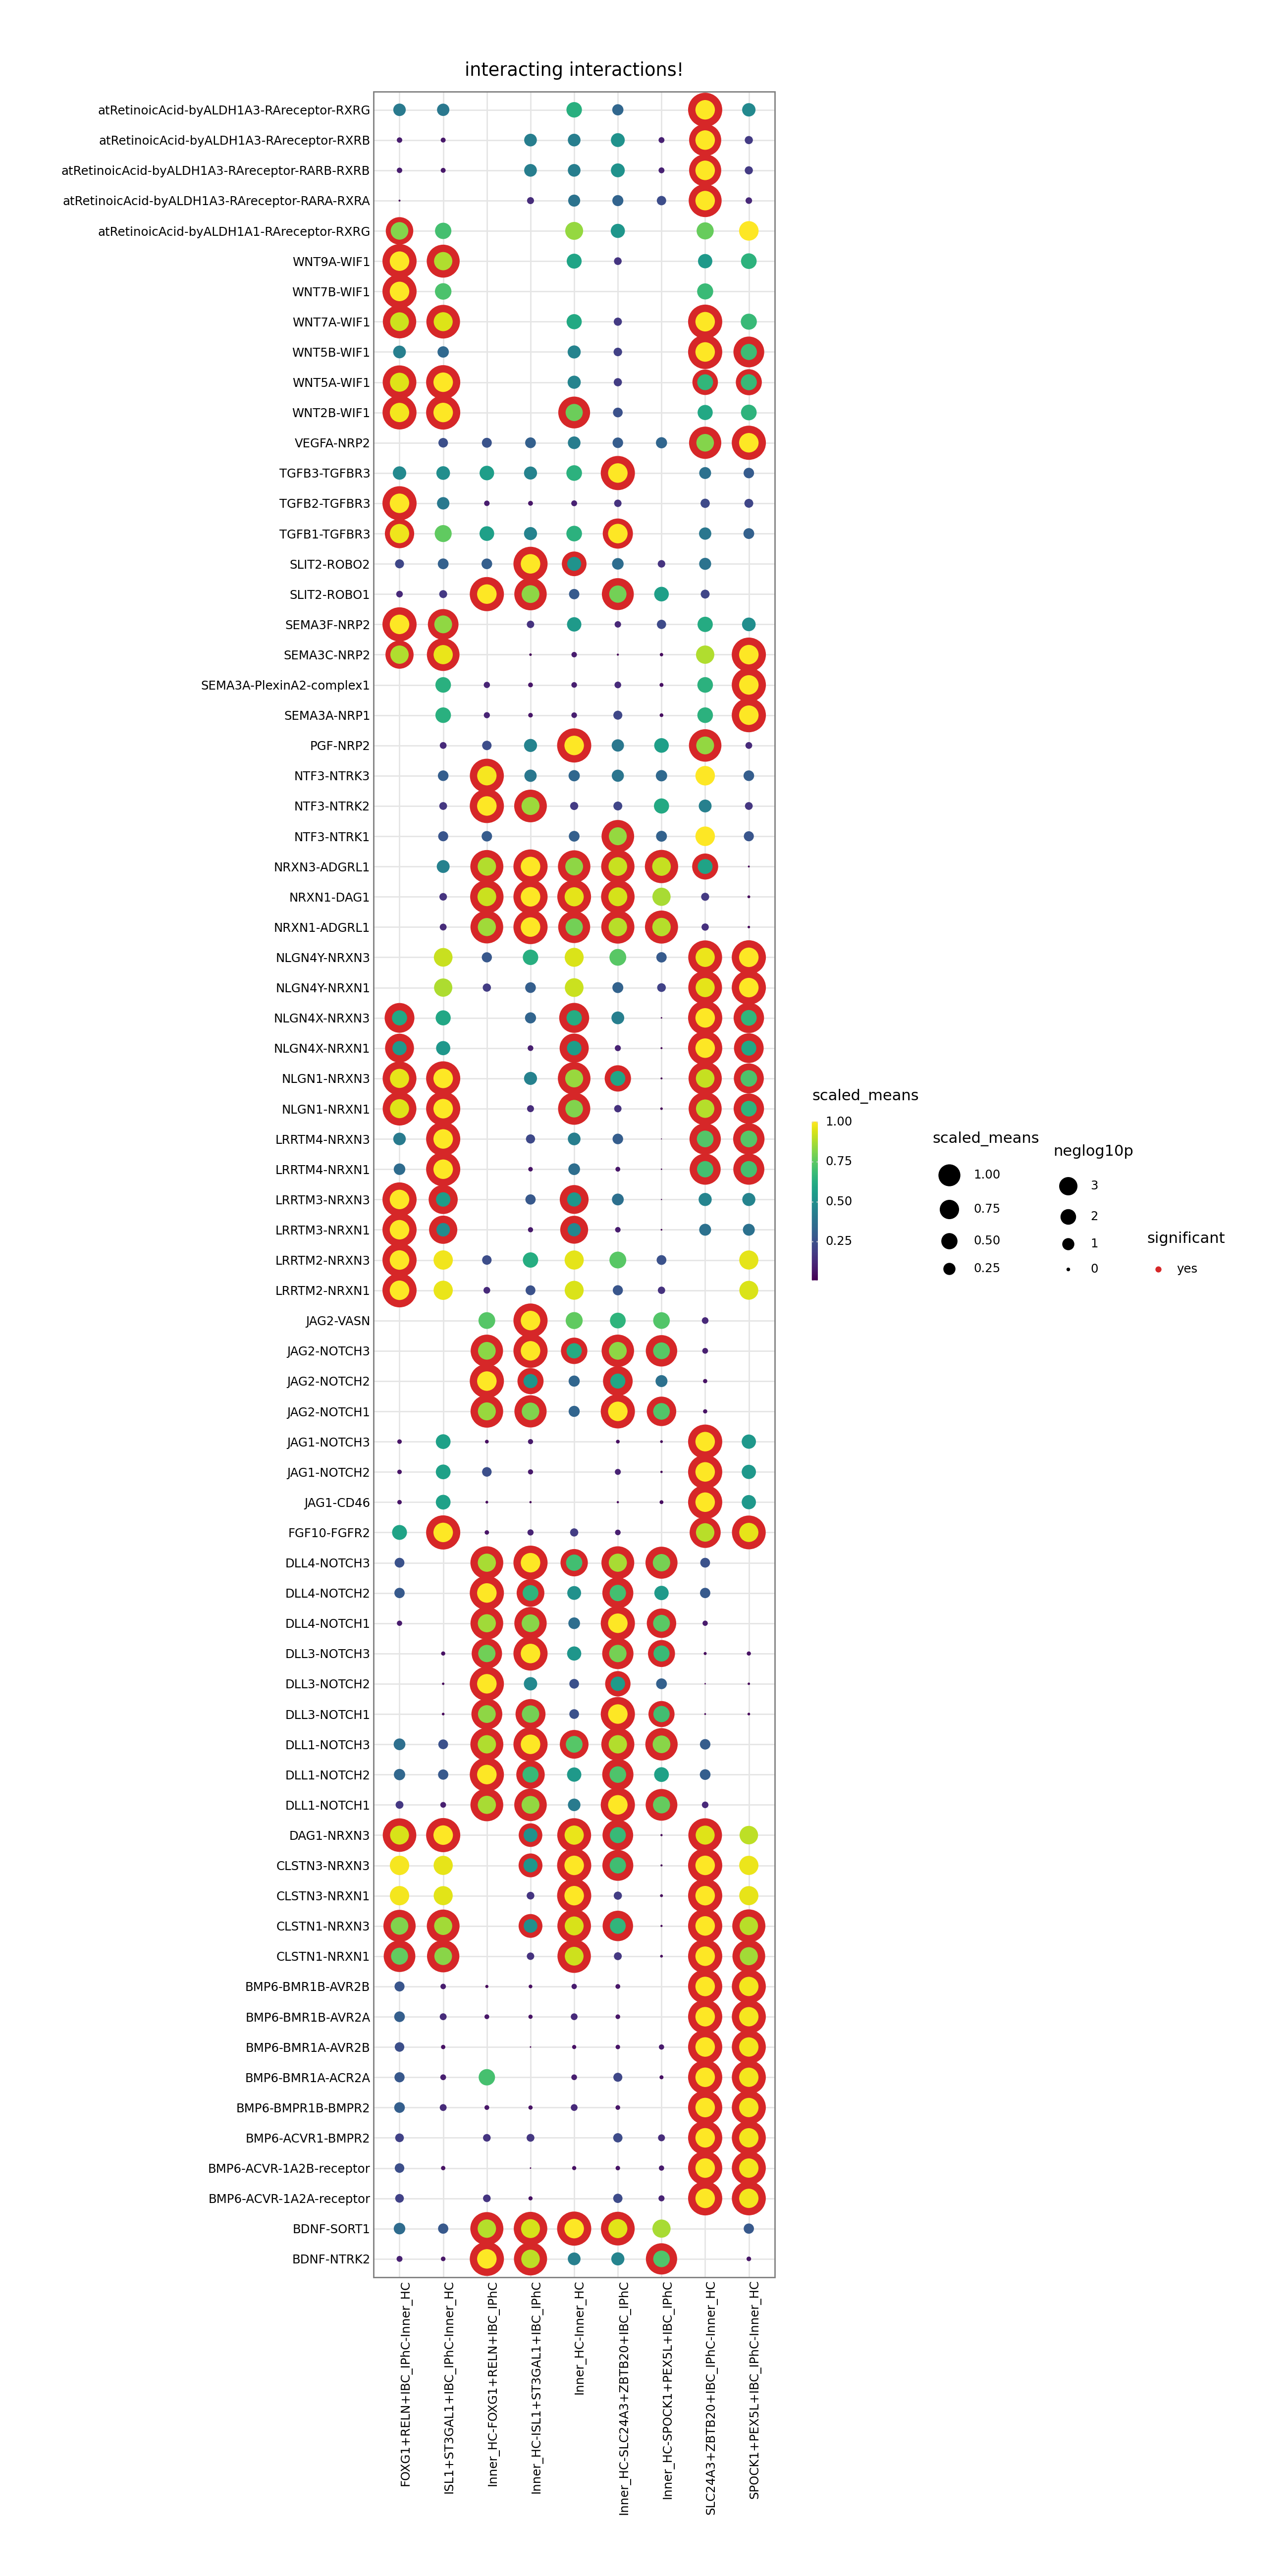

In [13]:
# TODO: How to specify the default plot resolution??
P=kpy.plot_cpdb(
    adata=adata_new_sub_late_IHC_IBC_IPH,
    cell_type1="Inner_HC",#FGFR3+PROX1+Lateral_PSD
    cell_type2=".",  # this means all cell-types
    means=means,
    pvals=pvals,
    celltype_key="cell_type_final_v4",
    genes=["WIF1","WHT5A","WHT2B","TGFBR3","NRP2","FGF10","SEMA3F","SEMA3C","SEMA3A","RXRA","RXRB","RXRG",
          "JAG1","BMP6","SLIT2","NTF3","NRXN3","NRXN1",    "JAG2","EHPHA5","DLL1","DLL3","DLL4","BDNF",],
    figsize=(12,25),
    title="interacting interactions!",
)
P
P.save(data_dir+'figures/figure2_S3/CPDB_SELECTE_IHC_IBC_IPH.pdf')

In [14]:
# read in the files
# 1) .h5ad file used for performing CellPhoneDB
adata_new_sub_late_OHC_DC

# 2) output from CellPhoneDB
means = pd.read_csv(data_dir+f"cpdb/test_cellphone_OHC_DC/statistical_analysis_means_01_14_2025_143747.txt", sep="\t")
pvals = pd.read_csv(data_dir+f"cpdb/test_cellphone_OHC_DC/statistical_analysis_pvalues_01_14_2025_143747.txt", sep="\t")
decon = pd.read_csv(data_dir+f"cpdb/test_cellphone_OHC_DC/statistical_analysis_deconvoluted_01_14_2025_143747.txt", sep="\t")

View of AnnData object with n_obs × n_vars = 251 × 46922
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'species', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'cell_type_final', 'low_ncounts', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'is_doublet_scrub', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_res2.0', 'cell_type_final_v4'
    var: 'gene_ids-0', 'feature_types-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'h

In [ ]:
p=kpy.plot_cpdb(
    adata=adata_new_sub_late_OHC_DC,
    cell_type1="Outer_HC",
    cell_type2=".",
    means=means,
    pvals=pvals,
    celltype_key="cell_type_final_v4",
    highlight_size=1,
    figsize=(8, 30),
)
p
p.save(data_dir+'figures/figure2_S3/cellphonedb_OHC_DC.pdf',limitsize=False)

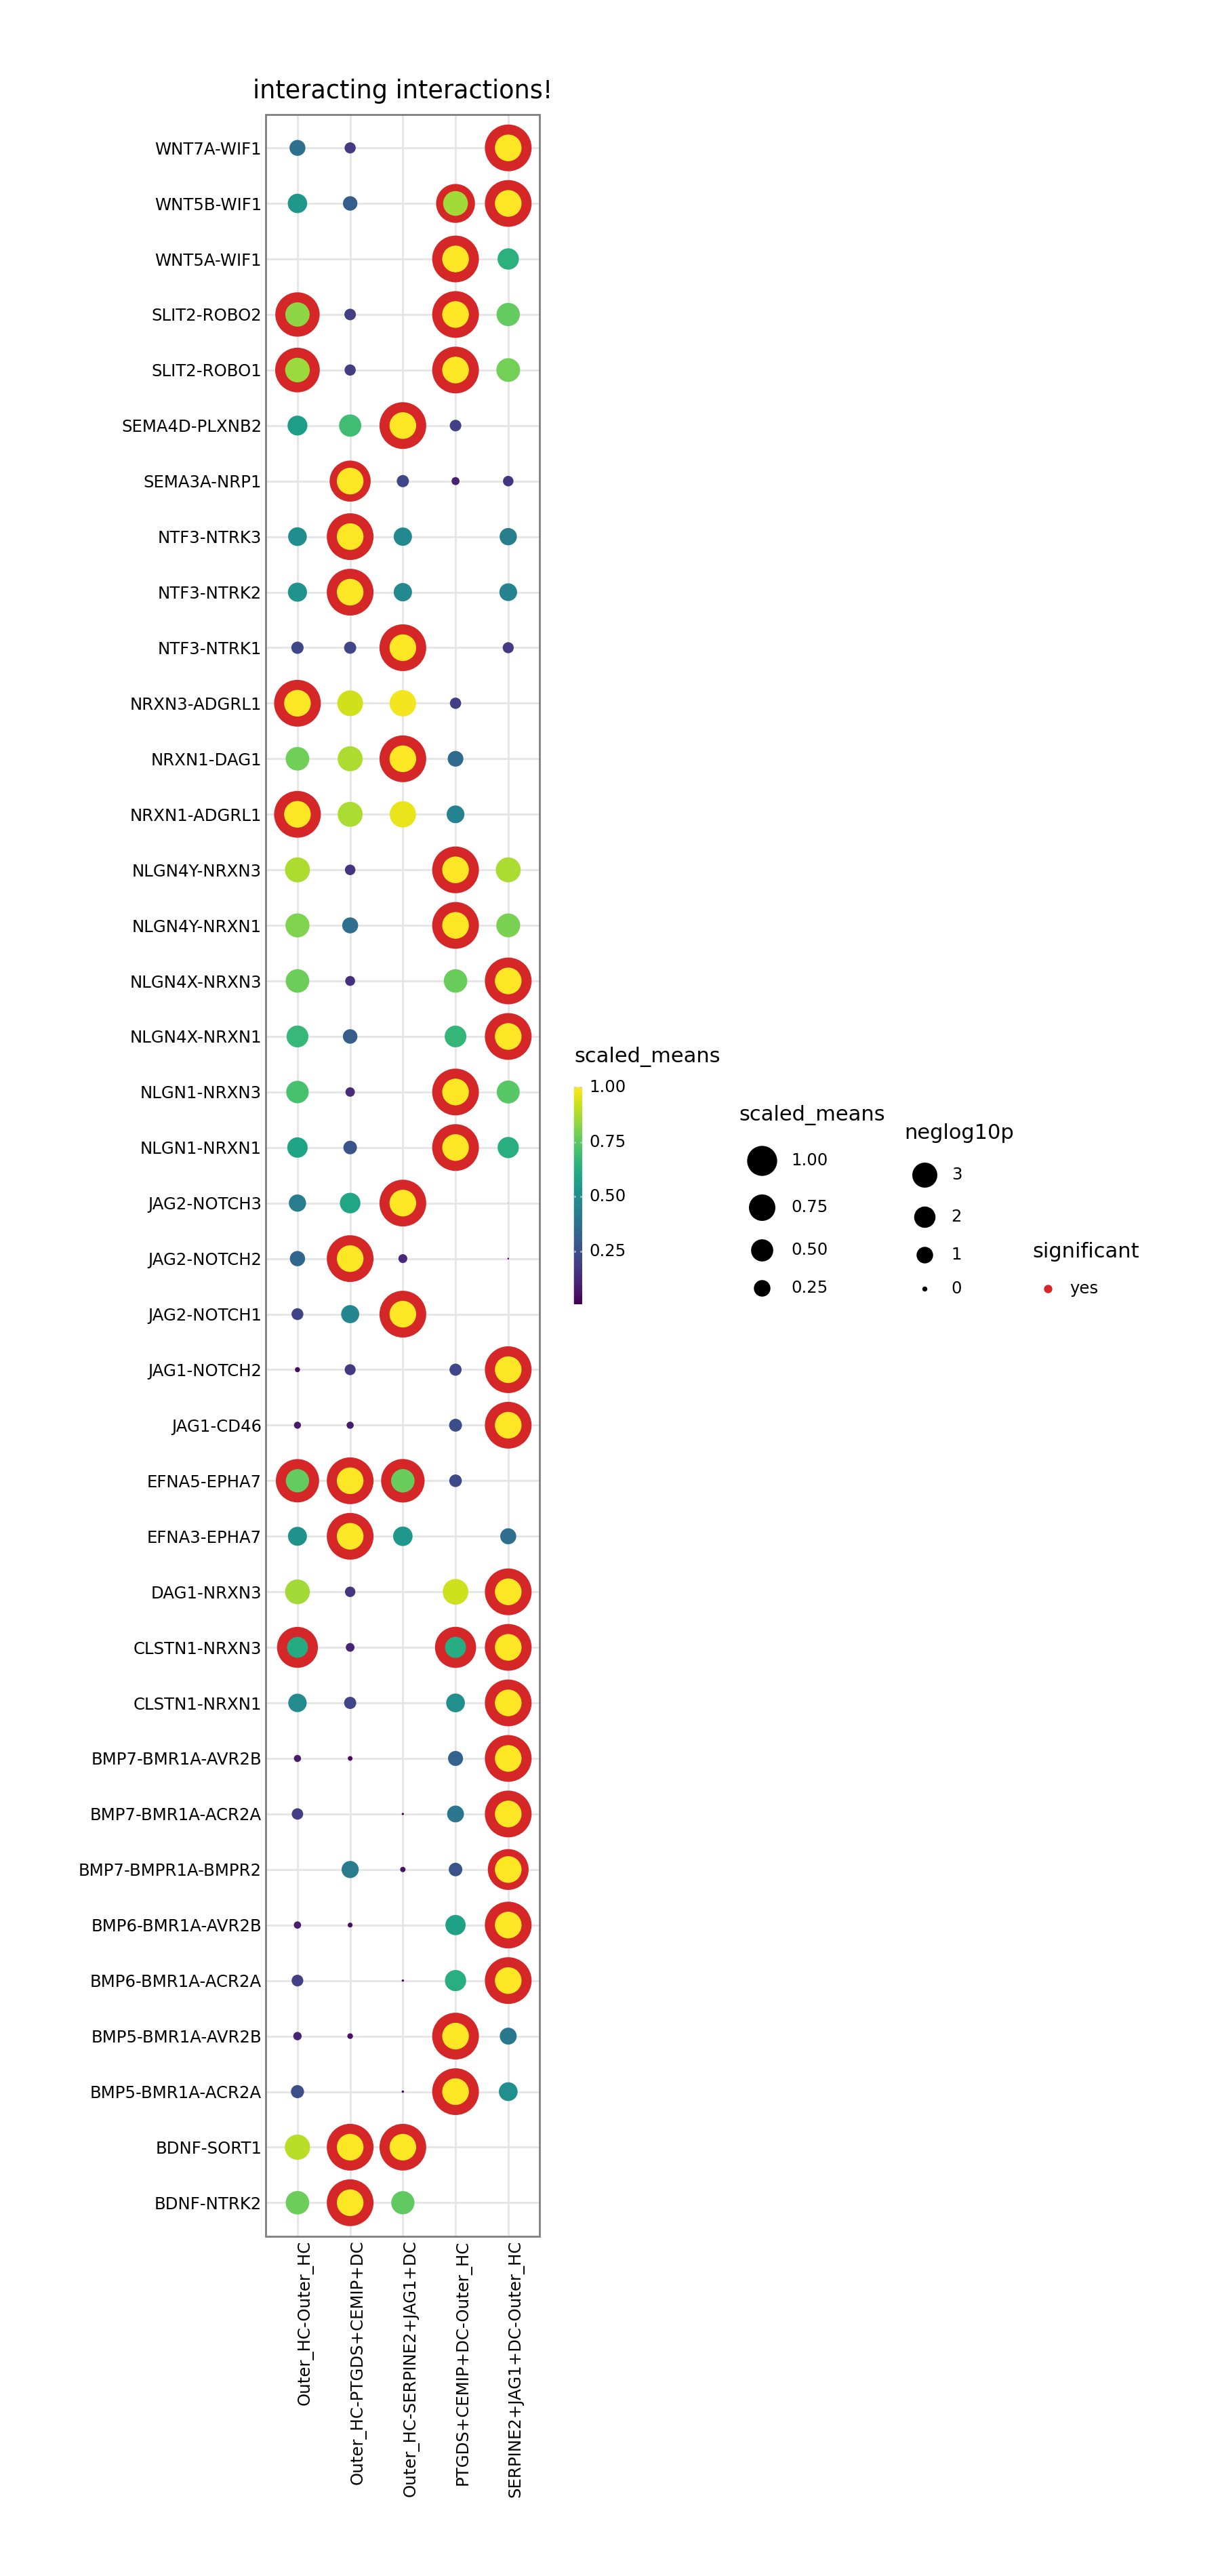

In [15]:
# TODO: How to specify the default plot resolution??
P=kpy.plot_cpdb(
    adata=adata_new_sub_late_OHC_DC,
    cell_type1="Outer_HC",#FGFR3+PROX1+Lateral_PSD
    cell_type2=".",  # this means all cell-types
    means=means,
    pvals=pvals,
    celltype_key="cell_type_final_v4",
    genes=["BDNF","EFNA5","EFNA3","NTF3","SEMA3A","SEMA4D","JAG2","WIF1","SLIT2","NRXN3","NRXN1","JAG1",
          "BMP5","BMP6","BMP7"],
    figsize=(8,18),
    title="interacting interactions!",
)
P
P.save(data_dir+'figures/figure2_S3/CPDB_SELECTE_OHC_DC.pdf')